# **Malaria Detection**

##<b>Problem Definition</b>
**The context:** Why is this problem important to solve?<br>
**The objectives:** What is the intended goal?<br>
**The key questions:** What are the key questions that need to be answered?<br>
**The problem formulation:** What is it that we are trying to solve using data science?

## <b>Data Description </b>

There are a total of 24,958 train and 2,600 test images (colored) that we have taken from microscopic images. These images are of the following categories:<br>


**Parasitized:** The parasitized cells contain the Plasmodium parasite which causes malaria<br>
**Uninfected:** The uninfected cells are free of the Plasmodium parasites<br>


###<b> Mount the Drive

In [1]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### <b>Loading libraries</b>

In [58]:
# Importing libraries required to load the data
import zipfile

import os

from PIL import Image

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import tensorflow as tf

from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler


# To ignore warnings
import warnings

warnings.filterwarnings('ignore')

# Remove the limit from the number of displayed columns and rows. It helps to see the entire dataframe while printing it
pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 200)

### <b>Let us load the data</b>

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same to your Google Drive. Then unzip the folder.

In [3]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/Colab Notebooks/Malaria Detection Deep Learning Abr 2025/cell_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:

    zip_ref.extractall()

The extracted folder has different folders for train and test data will contain the different sizes of images for parasitized and uninfected cells within the respective folder name.

The size of all images must be the same and should be converted to 4D arrays so that they can be used as an input for the convolutional neural network. Also, we need to create the labels for both types of images to be able to train and test the model.

Let's do the same for the training data first and then we will use the same code for the test data as well.

In [4]:
# Storing the path of the extracted "train" folder
train_dir = '/content/cell_images/train'

# Size of image so that each image has the same size
SIZE = 64

# Empty list to store the training images after they are converted to NumPy arrays
train_images = []

# Empty list to store the training labels (0 - uninfected, 1 - parasitized)
train_labels = []

In [5]:
# We will run the same code for "parasitized" as well as "uninfected" folders within the "train" folder
for folder_name in ['/parasitized/', '/uninfected/']:

    # Path of the folder
    images_path = os.listdir(train_dir + folder_name)

    for i, image_name in enumerate(images_path):

        try:

            # Opening each image using the path of that image
            image = Image.open(train_dir + folder_name + image_name)

            # Resizing each image to (64, 64)
            image = image.resize((SIZE, SIZE))

            # Converting images to arrays and appending that array to the empty list defined above
            train_images.append(np.array(image))

            # Creating labels for parasitized and uninfected images
            if folder_name == '/parasitized/':

                train_labels.append(1)

            else:

                train_labels.append(0)

        except Exception:

            pass

# Converting lists to arrays
train_images = np.array(train_images)

train_labels = np.array(train_labels)

In [6]:
# Storing the path of the extracted "test" folder
test_dir = '/content/cell_images/test'

# Size of image so that each image has the same size (it must be same as the train image size)
SIZE = 64

# Empty list to store the testing images after they are converted to NumPy arrays
test_images = []

# Empty list to store the testing labels (0 - uninfected, 1 - parasitized)
test_labels = []

In [7]:
# We will run the same code for "parasitized" as well as "uninfected" folders within the "test" folder
for folder_name in ['/parasitized/', '/uninfected/']:

    # Path of the folder
    images_path = os.listdir(test_dir + folder_name)

    for i, image_name in enumerate(images_path):

        try:
            # Opening each image using the path of that image
            image = Image.open(test_dir + folder_name + image_name)

            # Resizing each image to (64, 64)
            image = image.resize((SIZE, SIZE))

            # Converting images to arrays and appending that array to the empty list defined above
            test_images.append(np.array(image))

            # Creating labels for parasitized and uninfected images
            if folder_name == '/parasitized/':

                test_labels.append(1)

            else:

                test_labels.append(0)

        except Exception:

            pass

# Converting lists to arrays
test_images = np.array(test_images)

test_labels = np.array(test_labels)

###<b> Check the shape of train and test images

In [8]:
#Shape of images

print('Train Images Shape:', train_images.shape)

print('Test Images Shape:', test_images.shape)

Train Images Shape: (24958, 64, 64, 3)
Test Images Shape: (2600, 64, 64, 3)


###<b> Check the shape of train and test labels

In [9]:
# Shape of labels
print('Train Labels Shape:', train_labels.shape)

print('Test Labels Shape:', test_labels.shape)

Train Labels Shape: (24958,)
Test Labels Shape: (2600,)


####<b> Observations and insights: _____

Image dimensions: Both train and test images have the same dimensions (width, height, 3 color channels (RGB).

The training dataset is significantly larger than the testing data because is used to allow the model to learn patterns effectively. The testing dataset is used to evaluate the model's performance on unseen data.

The train and test labels are 1-dimensional arrays representing the class of each image (0 for uninfected, 1 for parasitized). Their shapes correspond to the number of images in each dataset.

Based on the labels' shapes, the training and testing datasets might have a roughly balanced distribution of uninfected and parasitized images. We need to plot the label distribution to further confirm this, it's important to have a balanced dataset.

### <b>Check the minimum and maximum range of pixel values for train and test images

In [10]:
# min and max function from numpy

print('Train Images Min:', np.min(train_images))

print('Train Images Max:', np.max(train_images))

print('Test Images Min:', np.min(test_images))

print('Test Images Max:', np.max(test_images))


Train Images Min: 0
Train Images Max: 255
Test Images Min: 0
Test Images Max: 255


####<b> Observations and insights: _____

Pixel Value Range: You would likely observe that the pixel values for both train and test images fall within the range of 0 to 255. This is the typical range for images represented using 8 bits per color channel (RGB).

Minimum Value: The minimum pixel value is probably 0. This indicates that some pixels in the images have no intensity in one or more color channels (black or very dark regions).

Maximum Value: The maximum pixel value is probably 255. This indicates that some pixels in the images have the highest possible intensity in one or more color channels (bright or white regions).

###<b> Count the number of values in both uninfected and parasitized

In [12]:
pd.value_counts(train_labels)

pd.value_counts(test_labels)


,count
1,1300
0,1300


In [13]:
# Display the shape of the first 5 images and the first 5 labels to verify the normalization
for i in range(5):
    print(f"Shape of image {i+1}: {train_images[i].shape}")
    print(f"Label of image {i+1}: {train_labels[i]}")

Shape of image 1: (64, 64, 3)
Label of image 1: 1
Shape of image 2: (64, 64, 3)
Label of image 2: 1
Shape of image 3: (64, 64, 3)
Label of image 3: 1
Shape of image 4: (64, 64, 3)
Label of image 4: 1
Shape of image 5: (64, 64, 3)
Label of image 5: 1


###<b>Normalize the images

In [14]:
train_images = (train_images / 255.0).astype('float32')

test_images = (test_images / 255).astype('float32')


####<b> Observations and insights: _____

The data is Balanced, so that's the ideal scenario.

The images are normalized to pixel values in a range between 0 and 1.

###<b> Plot to check if the data is balanced

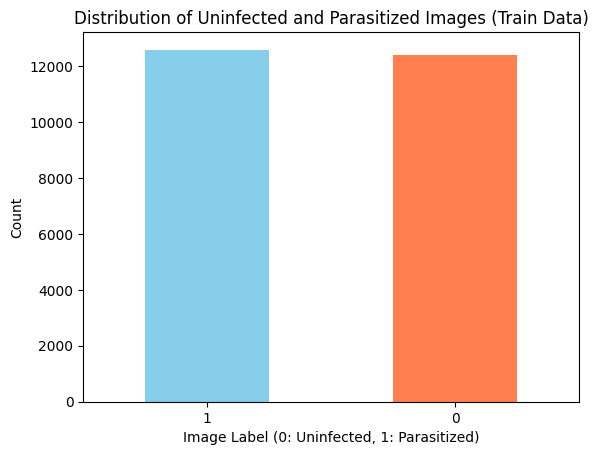

In [15]:
#Bar Plot
# Assuming 'train_labels' is your array of labels (0 or 1)
label_counts = pd.value_counts(train_labels)

# Create the bar plot
label_counts.plot(kind='bar', color=['skyblue', 'coral'])

plt.title('Distribution of Uninfected and Parasitized Images (Train Data)')
plt.xlabel('Image Label (0: Uninfected, 1: Parasitized)')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()


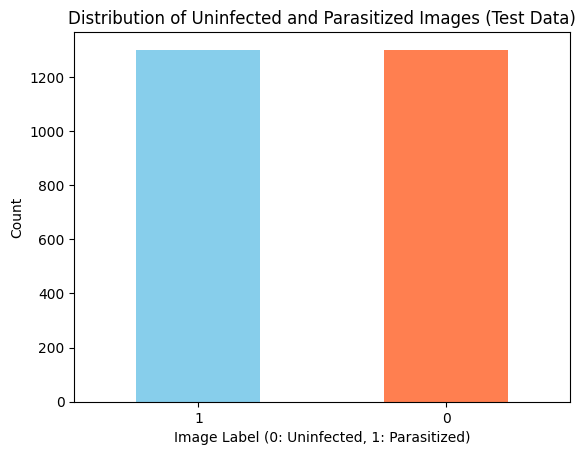

In [29]:
#Bar Plot
# Assuming 'test_labels' is your array of labels (0 or 1)
label_counts = pd.value_counts(test_labels)

# Create the bar plot
label_counts.plot(kind='bar', color=['skyblue', 'coral'])

plt.title('Distribution of Uninfected and Parasitized Images (Test Data)')
plt.xlabel('Image Label (0: Uninfected, 1: Parasitized)')
plt.ylabel('Count')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.show()

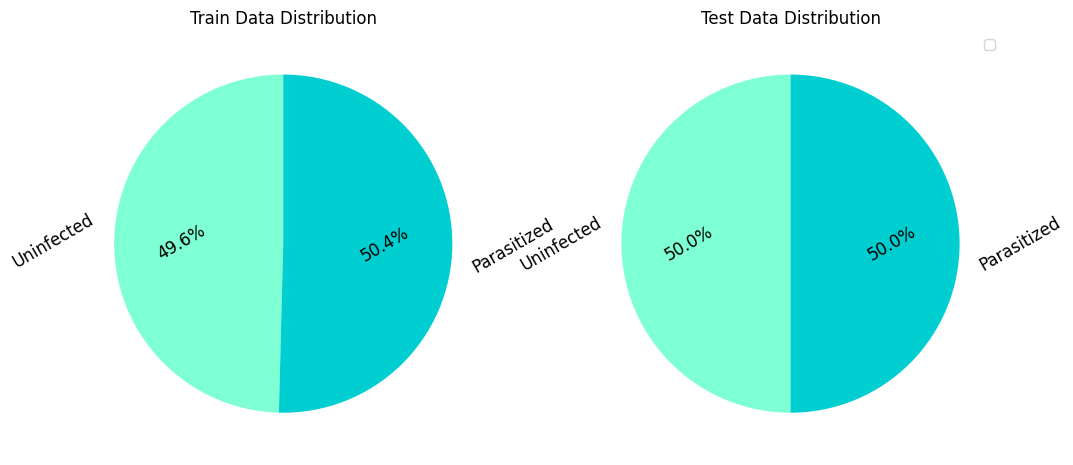

In [25]:
#pie-plot

# Assuming train_labels and test_labels are defined as in the provided code
train_counts = pd.value_counts(train_labels)
test_counts = pd.value_counts(test_labels)

labels = ['Uninfected', 'Parasitized']
sizes_train = [train_counts[0], train_counts[1]]
sizes_test = [test_counts[0], test_counts[1]]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#Define the colors for the slices

colors = ['aquamarine', 'darkturquoise']

#Adjust text properties

textprops = {'fontsize': 12, 'rotation' :30 }

plt.legend(labels, loc="best")

axes[0].pie(sizes_train, labels=labels, autopct='%1.1f%%', startangle=90, colors= colors, textprops = textprops)
axes[0].set_title('Train Data Distribution')

axes[1].pie(sizes_test, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, textprops = textprops)
axes[1].set_title('Test Data Distribution')

plt.show()


<Axes: ylabel='count'>

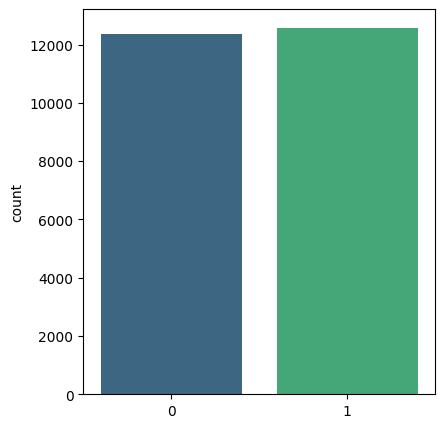

In [26]:
# Count plot

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

sns.countplot(x=train_labels, palette='viridis')

<Axes: ylabel='count'>

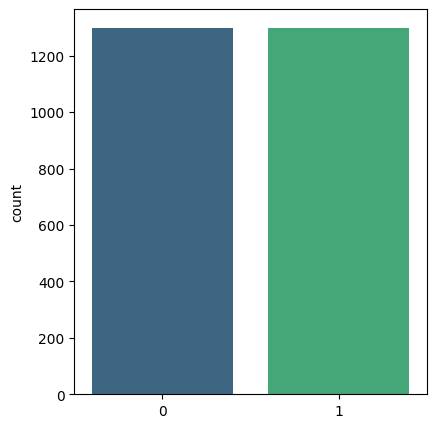

In [27]:
# Count plot

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)

sns.countplot(x=test_labels, palette='viridis')

####<b> Observations and insights: _____

**Data Balance:**

Overall: The dataset demonstrates a commendable balance between the two classes, Uninfected and Parasitized, in both the training and testing sets. This balance is crucial for training a robust and unbiased model that can accurately classify both types of cells.
Training Data: The training data exhibits a slight skew towards the Parasitized class, with approximately 50.4% of the images belonging to this category. However, the difference is relatively small and should not significantly impact model training.
Testing Data: The testing data showcases a near-perfect 50-50 split between the two classes. This even distribution ensures a reliable evaluation of the model's performance on unseen data.

**Distribution:**

Train vs. Test: The slight variation in class distribution between the train and test data might be due to random sampling during data splitting. The consistency in the overall balance suggests that this minor difference is unlikely to introduce significant bias.

Favorable Dataset: The balanced nature of the dataset, along with the near-perfect 50-50 distribution in the testing data, makes it a very favorable dataset for this problem statement. This should lead to better model training and reliable performance evaluation.

### <b>Data Exploration</b>
Let's visualize the images from the train data

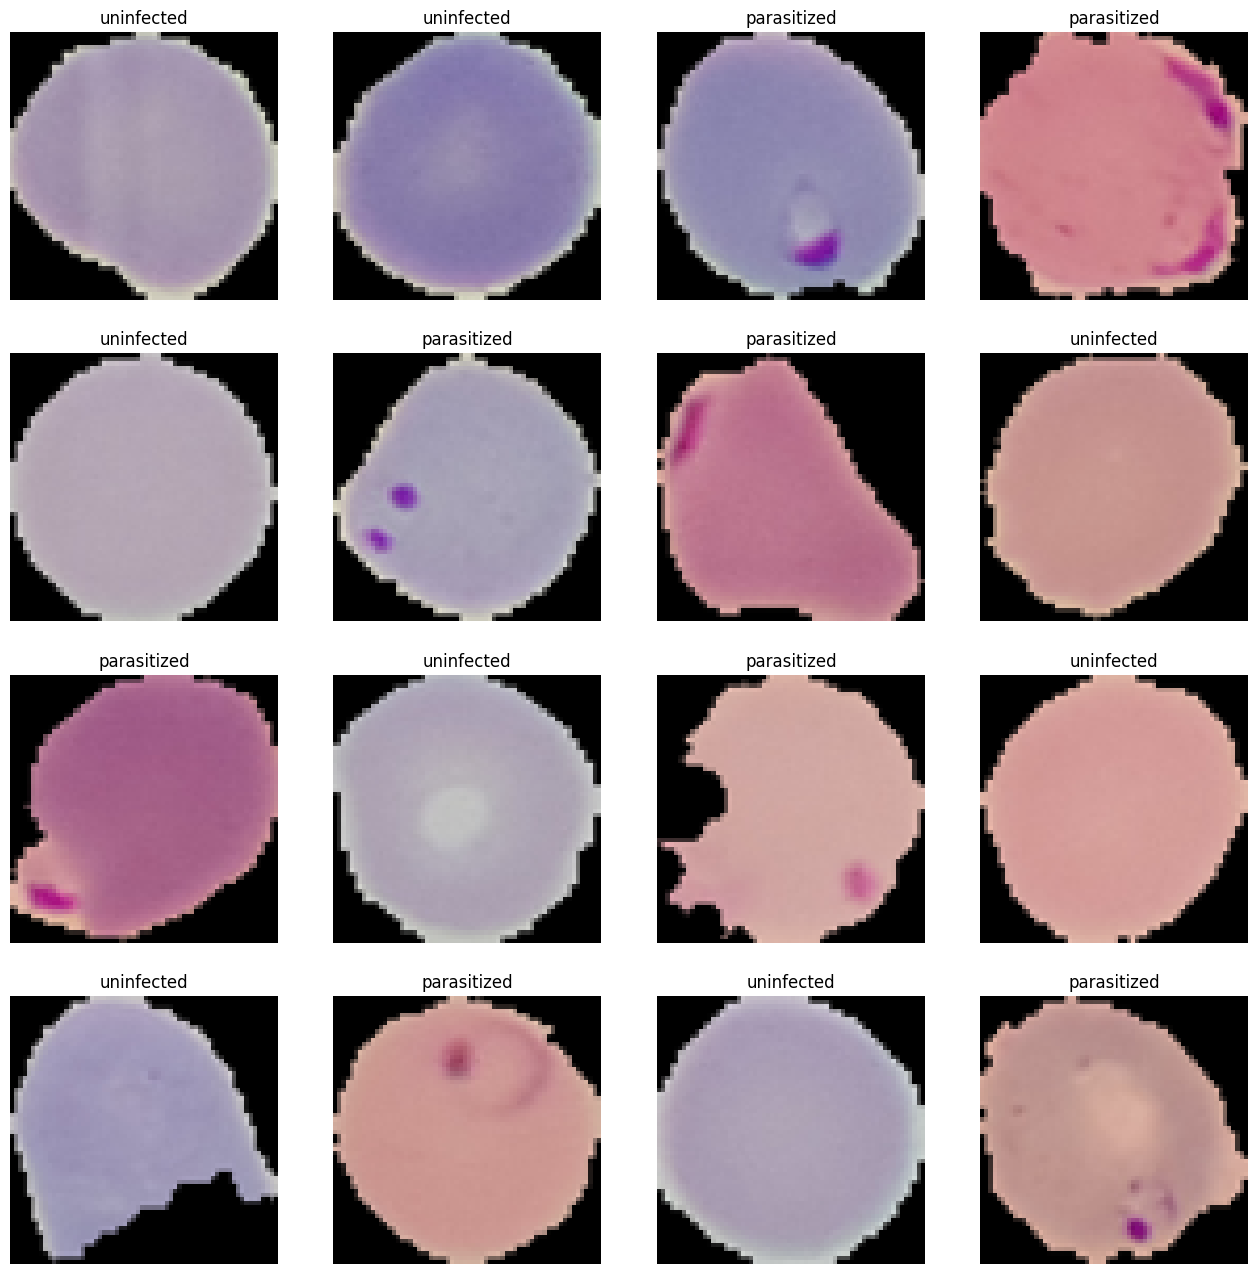

In [30]:
np.random.seed(42)

plt.figure(1, figsize = (16 , 16))

for n in range(1, 17):

    plt.subplot(4, 4, n)

    index = int(np.random.randint(0, train_images.shape[0], 1))

    if train_labels[index] == 1:

        plt.title('parasitized')

    else:
        plt.title('uninfected')

    plt.imshow(train_images[index])

    plt.axis('off')

####<b> Observations and insights: _____

Balanced Representation: The random sample appears to contain a roughly equal number of parasitized and uninfected cell images. This is a positive indication that the dataset is likely balanced overall, as the sample reflects the general distribution of the data.

Absence of Bias: The random selection process using the fixed seed has produced a sample that doesn't seem to exhibit any obvious bias towards either class. This suggests that the sampling method is effective in capturing a representative subset of the data.

Dataset Quality: Based on the visualized images, there are no immediate signs of significant data quality issues, such as corrupted images or mislabeling. However, a more thorough examination might be necessary to identify any subtle anomalies or potential challenges in the dataset.

###<b> Visualize the images with subplot(6, 6) and figsize = (12, 12)

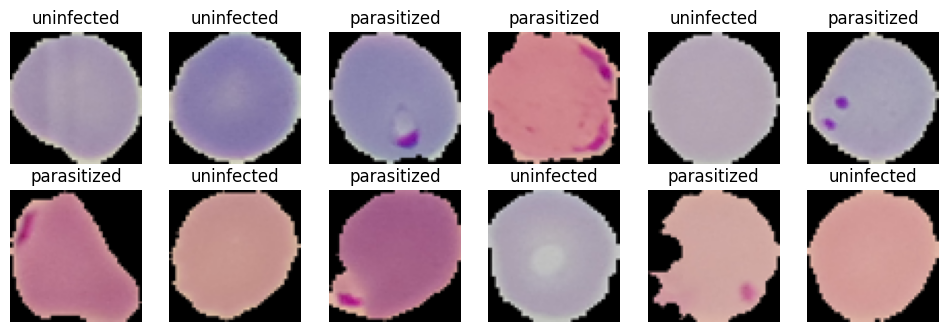

In [32]:
np.random.seed(42)

plt.figure(1, figsize = (12 , 12))

for n in range(1, 13):

    plt.subplot(6, 6, n)

    index = int(np.random.randint(0, train_images.shape[0], 1))

    if train_labels[index] == 1:

        plt.title('parasitized')

    else:
        plt.title('uninfected')

    plt.imshow(train_images[index])

    plt.axis('off')



####<b>Observations and insights:

Observations very similar to the last images.

Representative Sample: The visualized images seem to represent a fairly balanced mix of parasitized and uninfected cells. This suggests that the random sampling method, using a fixed seed for reproducibility, has effectively captured the overall distribution of the dataset.

Visual Distinctions: There are noticeable visual differences between the two classes. Parasitized cells often exhibit distinct features like the presence of the parasite (dark purple or black spots) within the red blood cells. Uninfected cells typically appear as regular, round red blood cells without any such internal structures.

Image Quality: The images generally appear to be of good quality, with clear cell structures and minimal noise or artifacts. This indicates that the dataset has been preprocessed or curated appropriately for deep learning tasks. However, a closer inspection of individual images might reveal subtle variations in image quality that could potentially affect model performance.

###<b> Plotting the mean images for parasitized and uninfected

In [35]:
# Function to find the mean
def find_mean_img(images, title):

    # Calculate the average
    mean_img = np.mean(images, axis = 0)[0]

    # Reshape it back to a matrix
    plt.imshow(mean_img)

    plt.title(f'Average {title}')

    plt.axis('off')

    plt.show()

    return mean_img


<b> Mean image for parasitized

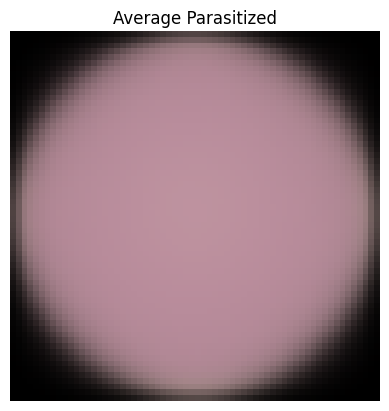

In [39]:
# If the label = 1 then the image is parasitized and if the label = 0 the the image in uninfected

parasitized_data = []  # Create a list to store the parasitized data

for img, label in zip(train_images, train_labels):

        if label == 1:

              parasitized_data.append([img])

parasitized_mean = find_mean_img(np.array(parasitized_data), 'Parasitized')   # find the mean

<b> Mean image for uninfected

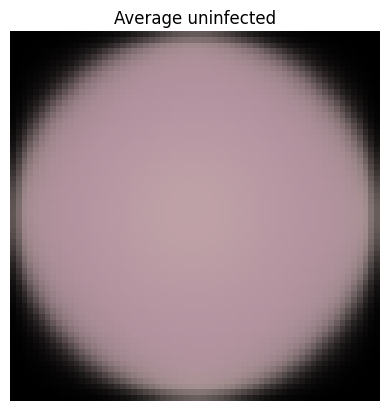

In [40]:
uninfected_data = []  # Create a list to store the uninfected data

for img, label in zip(train_images, train_labels):

        if label == 0:

              uninfected_data.append([img])

uninfected_mean = find_mean_img(np.array(uninfected_data), 'uninfected')   # find the mean



####<b> Observations and insights: _____

The mean images look similar overall, careful examination and analysis can reveal subtle differences.

### <b>Converting RGB to HSV of Images using OpenCV

###<b> Converting the train data

In [46]:
# prompt: convert the training data from RGB to HSV of Images using OpenCV

import cv2

hsv_images=[]   # to hold the HSV image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.cvtColor(train_images[i], cv2.COLOR_BGR2HSV)

  hsv_images.append(a)

hsv_images = np.array(hsv_images)


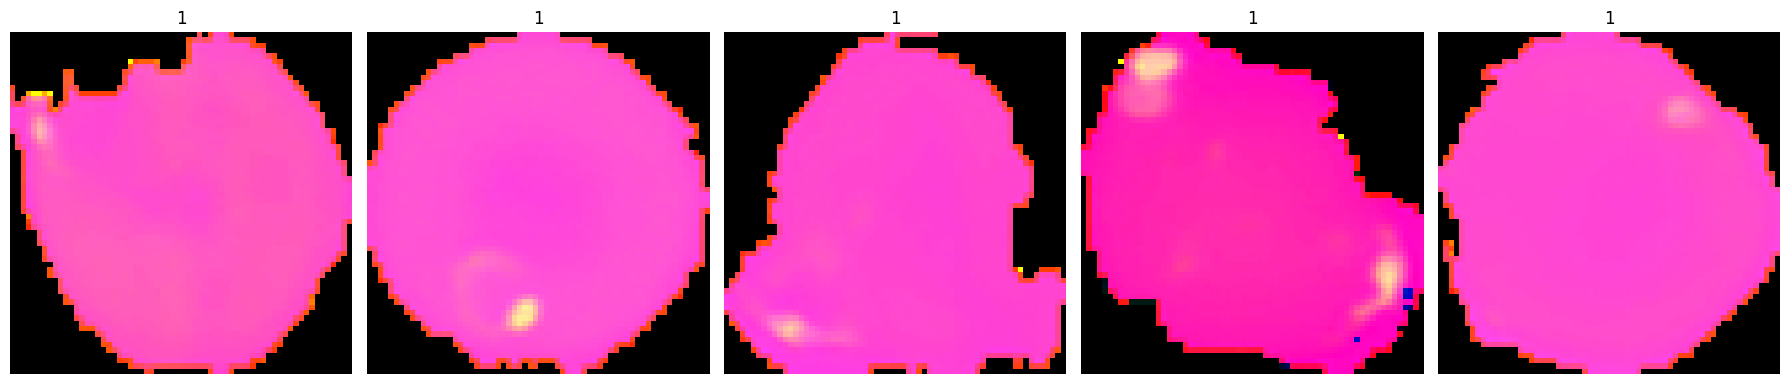

In [47]:
viewimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewimage):

  Title = train_labels[i]

  ax[t].set_title(Title)

  ax[t].imshow(hsv_images[i])

  ax[t].set_axis_off()

  fig.tight_layout()

###<b> Converting the test data

In [44]:
import cv2

hsv_images=[]   # to hold the HSV image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.cvtColor(test_images[i], cv2.COLOR_BGR2HSV)

  hsv_images.append(a)

hsv_images = np.array(hsv_images)

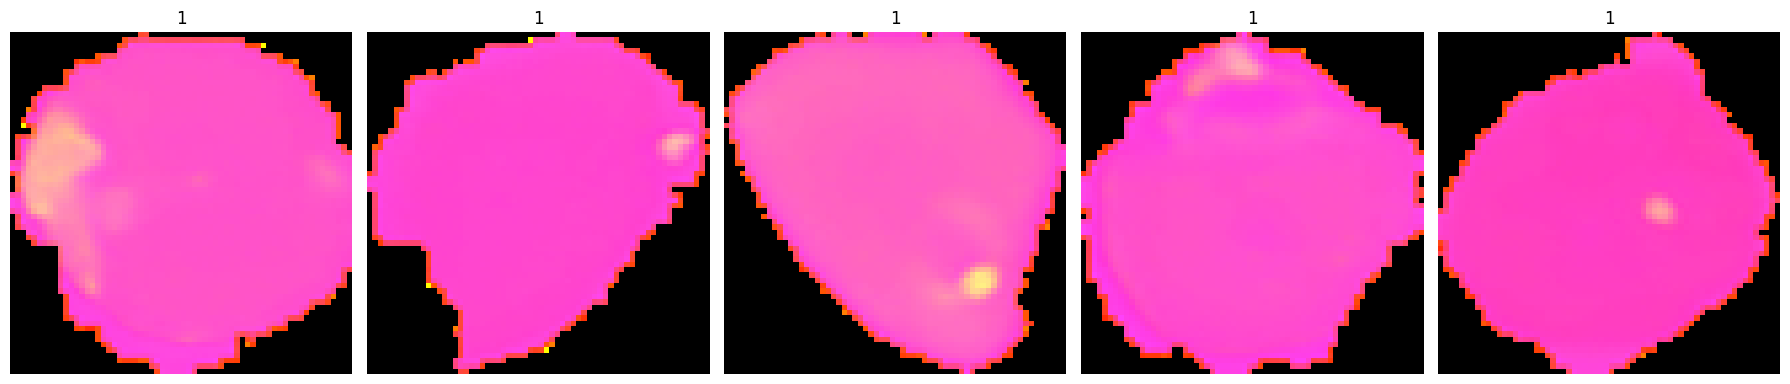

In [45]:
viewimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewimage):

  Title = test_labels[i]

  ax[t].set_title(Title)

  ax[t].imshow(hsv_images[i])

  ax[t].set_axis_off()

  fig.tight_layout()

####<b>Observations and insights: _____

The HSV images array provides a potentially valuable alternative representation of the data of the malaria detection. The separated channels of hue, saturation, and value can enhance color information, improve feature extraction, and contributes to increase model accuracy.

###<b> Processing Images using Gaussian Blurring

###<b> Gaussian Blurring on train data

In [48]:
gaussian_images=[]   # to hold the Gaussian image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.GaussianBlur(train_images[i], (5, 5), 0)
  gaussian_images.append(a)

gaussian_images = np.array(gaussian_images)

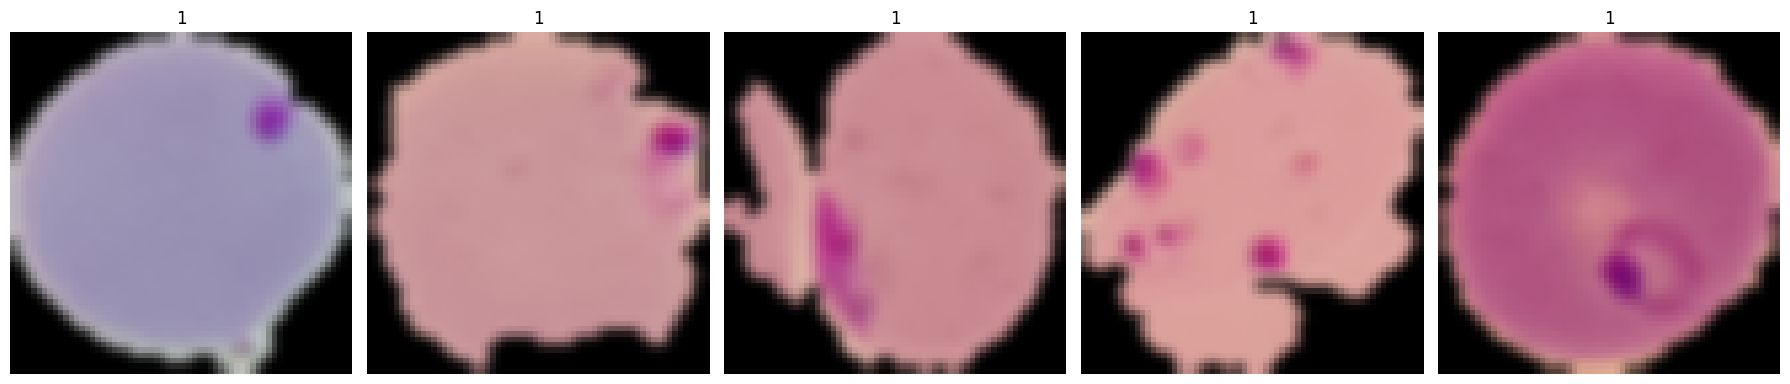

In [49]:
viewblurredimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewblurredimage):
  Title = train_labels[i]
  ax[t].set_title(Title)
  ax[t].imshow(gaussian_images[i])
  ax[t].set_axis_off()
  fig.tight_layout()

###<b> Gaussian Blurring on test data

In [52]:
gaussian_images=[]   # to hold the Gaussian image array

for i in np.arange(0, 100, 1): #converting the first 100 images

  a = cv2.GaussianBlur(test_images[i], (5, 5), 0)
  gaussian_images.append(a)

gaussian_images = np.array(gaussian_images)

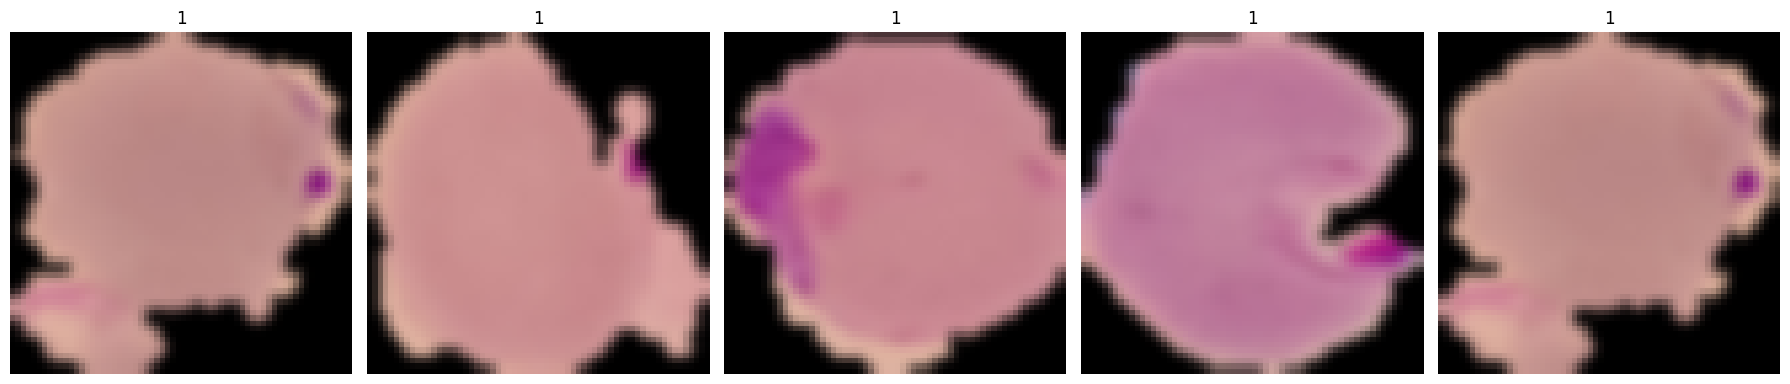

In [53]:
viewblurredimage = np.random.randint(1, 100, 5)

fig, ax = plt.subplots(1, 5, figsize = (18, 18))

for t, i in zip(range(5), viewblurredimage):
  Title = test_labels[i]
  ax[t].set_title(Title)
  ax[t].imshow(gaussian_images[i])
  ax[t].set_axis_off()
  fig.tight_layout()

####**Observations and insights: _____**

**Think About It:** Would blurring help us for this problem statement in any way? What else can we try?

Gaussian blurring is unlikely to have significantly helped improve the performance of the malaria detection model.

Preserving fine details and enhancing the visual cues related to the parasite are more crucial for accurate classification, and other image processing techniques might be more suitable.

Alternative Approaches: sharpening, contrast enhancement, edge detection.

In [59]:
# One Hot Encoding on the train and test labels

train_labels = to_categorical(train_labels, num_classes = 2)

test_labels = to_categorical(test_labels, num_classes = 2)

## **Model Building**

### **Base Model**

**Note:** The Base Model has been fully built and evaluated with all outputs shown to give an idea about the process of the creation and evaluation of the performance of a CNN architecture. A similar process can be followed in iterating to build better-performing CNN architectures.

###<b> Importing the required libraries for building and training our Model

####<B>One Hot Encoding the train and test labels

###<b> Building the model

In [ ]:
#

###<b> Compiling the model

<b> Using Callbacks

<b> Fit and train our Model

###<b> Evaluating the model on test data

<b> Plotting the confusion matrix

<b>Plotting the train and validation curves

So now let's try to build another model with few more add on layers and try to check if we can try to improve the model. Therefore try to build a model by adding few layers if required and altering the activation functions.

###<b> Model 1
####<b> Trying to improve the performance of our model by adding new layers


###<b> Building the Model

###<b> Compiling the model

<b> Using Callbacks

<b>Fit and Train the model

###<b> Evaluating the model

<b> Plotting the confusion matrix

<b> Plotting the train and the validation curves

###<b>Think about it:</b><br>
Now let's build a model with LeakyRelu as the activation function  

*  Can the model performance be improved if we change our activation function to LeakyRelu?
*  Can BatchNormalization improve our model?

Let us try to build a model using BatchNormalization and using LeakyRelu as our activation function.

###<b> Model 2 with Batch Normalization

###<b> Building the Model

###<b>Compiling the model

<b> Using callbacks

<b>Fit and train the model

<b>Plotting the train and validation accuracy

###<b>Evaluating the model

####<b>Observations and insights: ____

<b> Generate the classification report and confusion matrix

###**Think About It :**<br>

* Can we improve the model with Image Data Augmentation?
* References to image data augmentation can be seen below:
  *   [Image Augmentation for Computer Vision](https://www.mygreatlearning.com/blog/understanding-data-augmentation/)
  *   [How to Configure Image Data Augmentation in Keras?](https://machinelearningmastery.com/how-to-configure-image-data-augmentation-when-training-deep-learning-neural-networks/)





###<b>Model 3 with Data Augmentation

###<b> Use image data generator

###**Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



####<B>Visualizing Augmented images

####<b>Observations and insights: ____

###<b>Building the Model

<b>Using Callbacks

<b> Fit and Train the model

###<B>Evaluating the model

<b>Plot the train and validation accuracy

<B>Plotting the classification report and confusion matrix

<b> Now, let us try to use a pretrained model like VGG16 and check how it performs on our data.

### **Pre-trained model (VGG16)**
- Import VGG16 network upto any layer you choose
- Add Fully Connected Layers on top of it

###<b>Compiling the model

<b> using callbacks

<b>Fit and Train the model

<b>Plot the train and validation accuracy

###**Observations and insights: _____**

*   What can be observed from the validation and train curves?

###<b> Evaluating the model

<b>Plotting the classification report and confusion matrix

###<b>Think about it:</b>
*  What observations and insights can be drawn from the confusion matrix and classification report?
*  Choose the model with the best accuracy scores from all the above models and save it as a final model.


####<b> Observations and Conclusions drawn from the final model: _____



**Improvements that can be done:**<br>


*  Can the model performance be improved using other pre-trained models or different CNN architecture?
*  You can try to build a model using these HSV images and compare them with your other models.

#### **Insights**

####**Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

####**Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

####**Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?